#  Customer Lifetime Value (CLTV) Prediction
### Predict how much each customer will spend in the next N months


## 1. Import Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

%matplotlib inline

## 2. Load Dataset

In [53]:
df = pd.read_csv('OnlineRetail_Cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [54]:
df.head()

,InvoiceDate,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate.1,Year,Quarter,MonthName,DayName,TotalPrice
0,2010-12-01,17850.0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,United Kingdom,2010-12-01,2010,4,December,Wednesday,15.30
1,2010-12-01,17850.0,536365,71053,White Metal Lantern,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
2,2010-12-01,17850.0,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,United Kingdom,2010-12-01,2010,4,December,Wednesday,22.00
3,2010-12-01,17850.0,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
4,2010-12-01,17850.0,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34


In [55]:
print(f'Date range: {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')

Date range: 2010-12-01 00:00:00 → 2011-12-09 00:00:00


In [56]:
df.shape

(333045, 14)

## 3. Set Prediction Duration


In [57]:
# ✅ Change this value to 1, 3, or 6 
duration_months = 1

print(f'Prediction duration set to: {duration_months} month{"s" if duration_months > 1 else ""}')

Prediction duration set to: 1 month


## 4. Time-Based Split

**Key idea:** Use customer behavior **before** the split date as features,  
and what they **actually spent after** as the LTV target.

```
oldest date ──────────── split_date ──────────── latest date
    [      FEATURES (train period)     ] [  TARGET (LTV period)  ]
```

In [58]:
split_date = df['InvoiceDate'].max() - pd.DateOffset(months=duration_months)

train_df  = df[df['InvoiceDate'] <  split_date].copy()
future_df = df[df['InvoiceDate'] >= split_date].copy()

print(f'Prediction duration       : {duration_months} month{"s" if duration_months > 1 else ""}')
print(f'Split date                : {split_date.date()}')
print(f'Train period transactions : {len(train_df):,}')
print(f'Future period transactions: {len(future_df):,}')
print(f'Train  date range: {train_df["InvoiceDate"].min().date()} → {train_df["InvoiceDate"].max().date()}')
print(f'Future date range: {future_df["InvoiceDate"].min().date()} → {future_df["InvoiceDate"].max().date()}')

Prediction duration       : 1 month
Split date                : 2011-11-09
Train period transactions : 276,116
Future period transactions: 56,929
Train  date range: 2010-12-01 → 2011-11-08
Future date range: 2011-11-09 → 2011-12-09


## 5. Build Target: Actual LTV (next N months)

In [59]:
if 'TotalPrice' not in future_df.columns:
    future_df['TotalPrice'] = future_df['Quantity'] * future_df['UnitPrice']

# Sum of spending per customer in the FUTURE period
future_ltv = future_df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
future_ltv.columns = ['CustomerID', f'LTV_{duration_months}months']

print(f'Customers with known {duration_months}-month LTV: {len(future_ltv):,}')
print(f'\nLTV stats:')
print(future_ltv[f'LTV_{duration_months}months'].describe())

Customers with known 1-month LTV: 1,604



LTV stats:
count     1604.000000
mean       413.476733
std        797.476514
min          1.900000
25%        142.355000
50%        270.710000
75%        464.497500
max      19415.700000
Name: LTV_1months, dtype: float64


## 6. Feature Engineering (on train period only)

We build **customer-level features** from the train period only — no future data leaks in.

In [60]:
reference_date = train_df['InvoiceDate'].max()

# ── RFM ──────────────────────────────────────────────────
rfm = train_df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

# Average Order Value
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Customer Lifetime
lifetime = train_df.groupby('CustomerID')['InvoiceDate'].agg(
    lambda x: (x.max() - x.min()).days
).reset_index()
lifetime.columns = ['CustomerID', 'CustomerLifetime']
rfm = rfm.merge(lifetime, on='CustomerID')

# Purchase Rate
rfm['PurchaseRate'] = rfm['Frequency'] / rfm['CustomerLifetime'].replace(0, 1)

# Average Basket Size
avg_basket = train_df.groupby('CustomerID')['Quantity'].mean().reset_index()
avg_basket.columns = ['CustomerID', 'AvgBasketSize']
rfm = rfm.merge(avg_basket, on='CustomerID')

print(f'Customers in train period: {len(rfm):,}')
rfm.head()

Customers in train period: 3,926


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,CustomerLifetime,PurchaseRate,AvgBasketSize
0,12347.0,8,6,3089.91,514.985000,328,0.018293,10.974194
1,12348.0,217,3,90.20,30.066667,110,0.027273,23.333333
2,12350.0,279,1,294.40,294.400000,0,1.000000,12.250000
3,12352.0,5,7,1130.94,161.562857,260,0.026923,7.575758
4,12353.0,173,1,29.30,29.300000,0,1.000000,7.000000


## 7. Merge Features + Target

In [61]:
# Only keep customers present in BOTH periods
data = rfm.merge(future_ltv, on='CustomerID', how='inner')

print(f'Customers with features AND known LTV: {len(data):,}')
data.head()

Customers with features AND known LTV: 1,342


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,CustomerLifetime,PurchaseRate,AvgBasketSize,LTV_1months
0,12347.0,8,6,3089.91,514.985000,328,0.018293,10.974194,224.82
1,12358.0,119,1,369.06,369.060000,0,1.000000,10.444444,509.16
2,12362.0,4,9,3655.70,406.188889,260,0.034615,9.060606,443.24
3,12364.0,9,2,810.96,405.480000,72,0.027778,15.000000,295.32
4,12375.0,67,1,158.50,158.500000,0,1.000000,9.111111,124.80


## 8. EDA on LTV Distribution

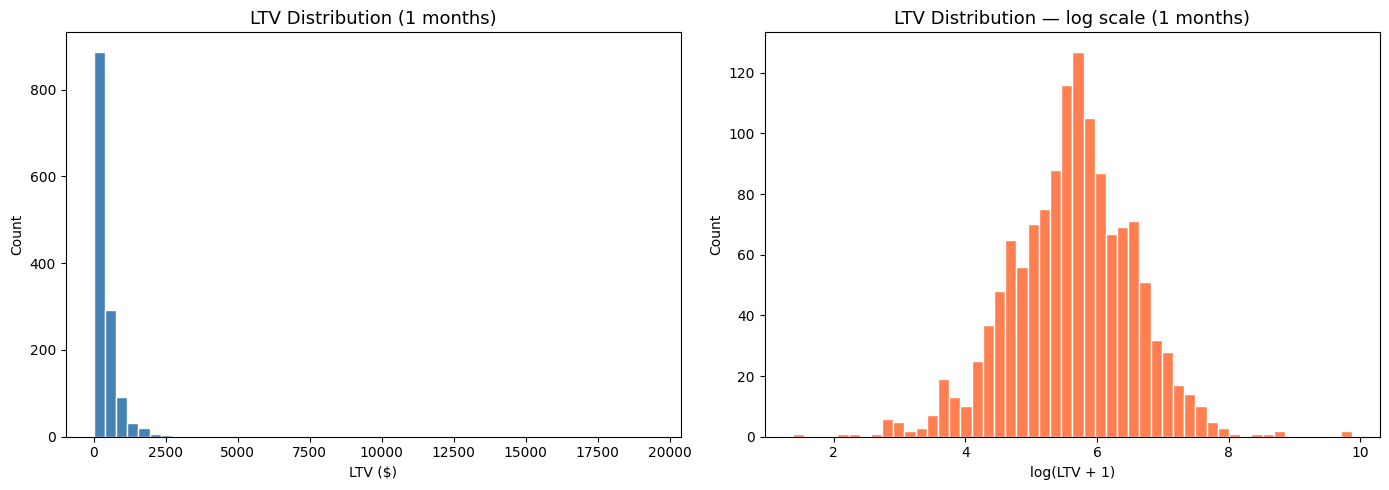

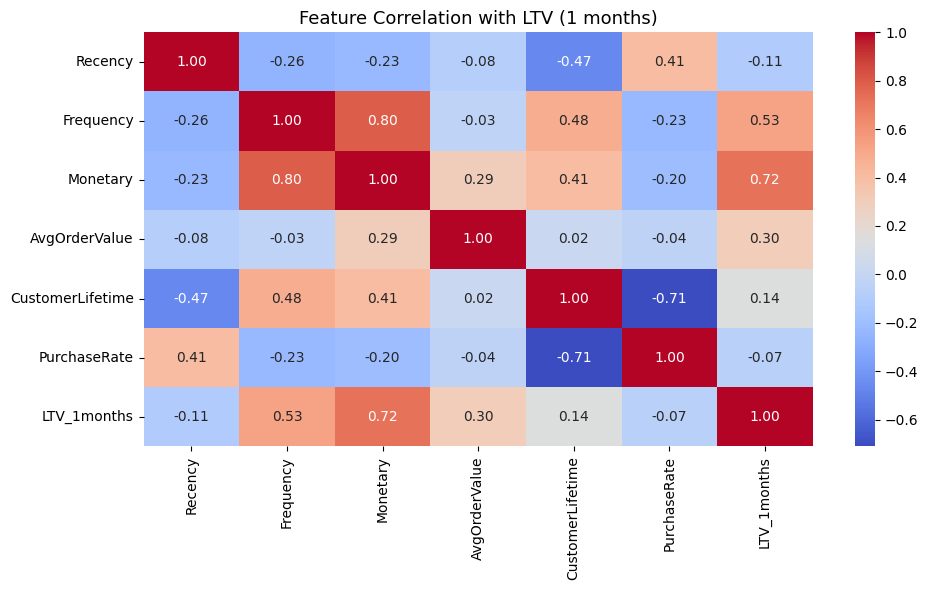

In [62]:
ltv_col = f'LTV_{duration_months}months'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data[ltv_col], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'LTV Distribution ({duration_months} months)', fontsize=13)
axes[0].set_xlabel('LTV ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(data[ltv_col]), bins=50, color='coral', edgecolor='white')
axes[1].set_title(f'LTV Distribution — log scale ({duration_months} months)', fontsize=13)
axes[1].set_xlabel('log(LTV + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
corr_cols = ['Recency','Frequency','Monetary','AvgOrderValue','CustomerLifetime','PurchaseRate', ltv_col]
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title(f'Feature Correlation with LTV ({duration_months} months)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Prepare Features & Target

In [63]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
                'CustomerLifetime', 'PurchaseRate', 'AvgBasketSize']

X = data[feature_cols]
y = data[f'LTV_{duration_months}months']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Target   : LTV_{duration_months}months')
print(f'Range    : ${y.min():.2f} – ${y.max():.2f}')
print(f'Mean     : ${y.mean():.2f}')

Features : 7
Samples  : 1342
Target   : LTV_1months
Range    : $2.95 – $19415.70
Mean     : $440.76


## 10. Train / Test Split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')

X_train shape : (1006, 7)
X_test  shape : (336, 7)


## 11. Define Models

In [65]:
lr   = LinearRegression()
ridge= Ridge()
lasso= Lasso()
dtr  = DecisionTreeRegressor(random_state=42)
rfr  = RandomForestRegressor(random_state=42)
gbr  = GradientBoostingRegressor(random_state=42)
knnr = KNeighborsRegressor()
xgbr = XGBRegressor(eval_metric='rmse', random_state=42)

## 12. Hyperparameter Grids

In [66]:
param1 = {'regressor': [lr]}

param2 = {
    'regressor': [ridge],
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

param3 = {
    'regressor': [lasso],
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]
}

param4 = {
    'regressor': [dtr],
    'regressor__max_depth': [5, 10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

param5 = {
    'regressor': [rfr],
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [5, 10, 20, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2']
}

param6 = {
    'regressor': [gbr],
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0]
}

param7 = {
    'regressor': [knnr],
    'regressor__n_neighbors': [3, 5, 7, 9],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan']
}

param8 = {
    'regressor': [xgbr],
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

params = [param1, param2, param3, param4, param5, param6, param7, param8]

## 13. Pipeline + GridSearchCV

In [67]:
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', lr)
])

gs = GridSearchCV(
    pipeline,
    params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

gs.fit(X_train, y_train)

Fitting 5 folds for each of 385 candidates, totalling 1925 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'regressor': [LinearRegression()]}, {'regressor': [Ridge()], 'regressor__alpha': [0.1, 1.0, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

## 14. Best Model

In [68]:
print(f'Best CV MAE  : ${-gs.best_score_:.2f}')
print(f'Best Params  : {gs.best_params_}')

Best CV MAE  : $237.31
Best Params  : {'regressor': Lasso(), 'regressor__alpha': 10.0}


## 15. Evaluate on Test Set

MAE  : $238.03
RMSE : $626.54
R²   : 0.6453


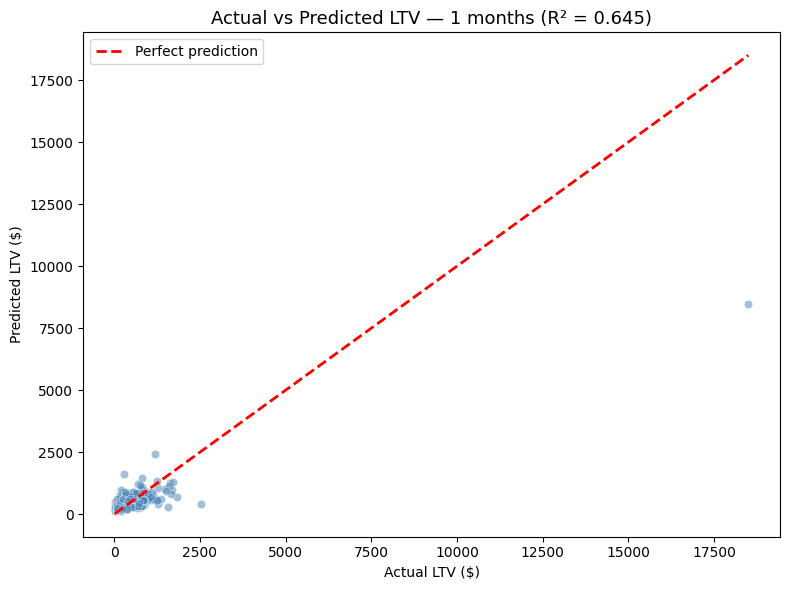

In [69]:
y_pred = gs.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE  : ${mae:.2f}')
print(f'RMSE : ${rmse:.2f}')
print(f'R²   : {r2:.4f}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual LTV ($)')
plt.ylabel('Predicted LTV ($)')
plt.title(f'Actual vs Predicted LTV — {duration_months} months (R² = {r2:.3f})', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

## 16. Residual Analysis

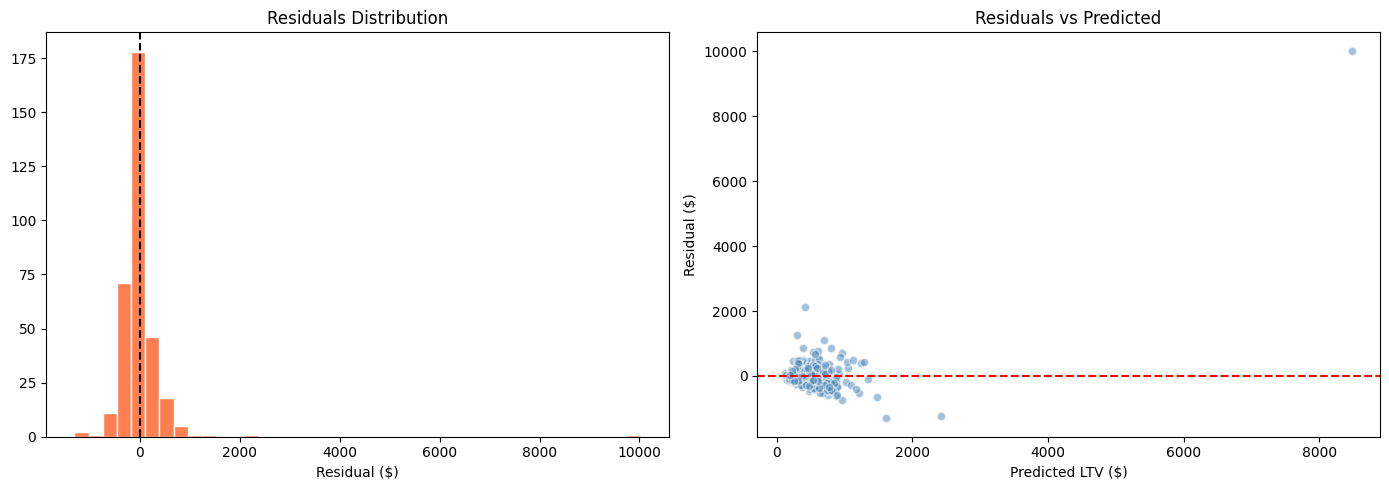

In [70]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Residuals Distribution')
axes[0].set_xlabel('Residual ($)')

axes[1].scatter(y_pred, residuals, alpha=0.5, color='steelblue', edgecolors='white')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted LTV ($)')
axes[1].set_ylabel('Residual ($)')

plt.tight_layout()
plt.show()

## 17. Feature Importance

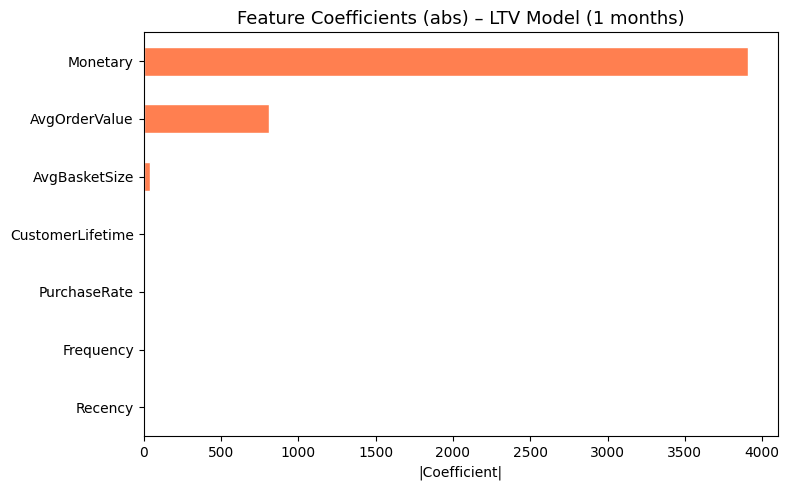

In [71]:
best_model = gs.best_estimator_.named_steps['regressor']

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    importance.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Feature Importance – LTV Model ({duration_months} months)', fontsize=13)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_), index=feature_cols)
    coef = coef.sort_values(ascending=True)
    plt.figure(figsize=(8, 5))
    coef.plot(kind='barh', color='coral', edgecolor='white')
    plt.title(f'Feature Coefficients (abs) – LTV Model ({duration_months} months)', fontsize=13)
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model type.')

## 18. LTV Segment Analysis

              Customers  Avg_Predicted_LTV  Total_Predicted  Avg_Recency  \
LTV_Segment                                                                
Low Value           448             223.81        100265.55        96.01   
Medium Value        447             352.31        157482.67        49.83   
High Value          447             748.90        334759.12        31.30   

              Avg_Frequency  
LTV_Segment                  
Low Value              2.42  
Medium Value           4.60  
High Value            11.42  


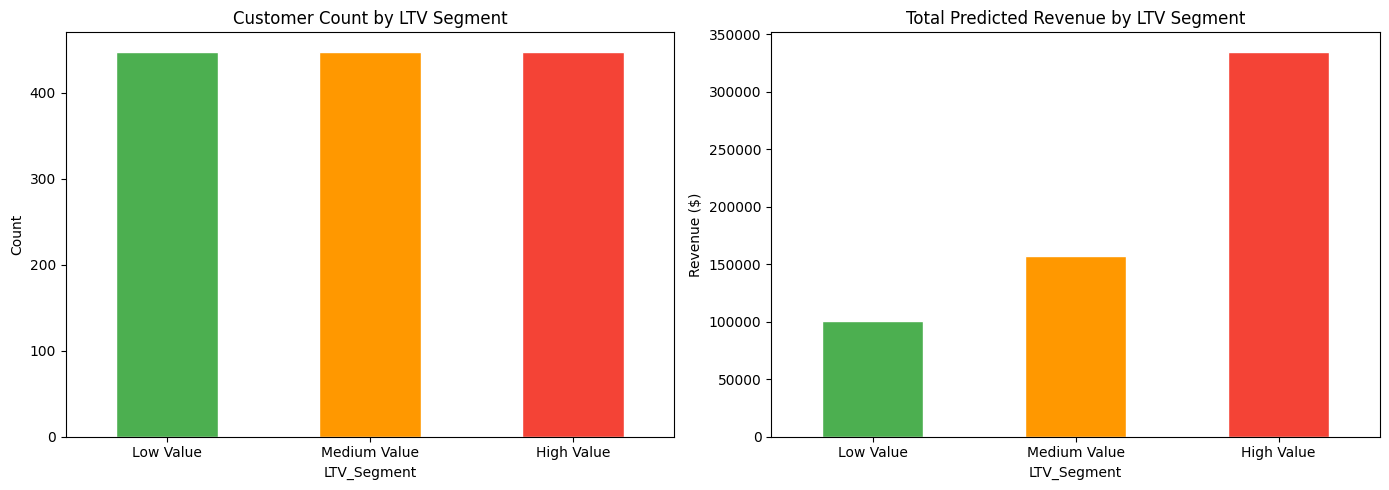

In [72]:
data['Predicted_LTV'] = gs.predict(X)

data['LTV_Segment'] = pd.qcut(
    data['Predicted_LTV'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

segment_summary = data.groupby('LTV_Segment').agg(
    Customers         = ('CustomerID',    'count'),
    Avg_Predicted_LTV = ('Predicted_LTV', 'mean'),
    Total_Predicted   = ('Predicted_LTV', 'sum'),
    Avg_Recency       = ('Recency',        'mean'),
    Avg_Frequency     = ('Frequency',      'mean')
).round(2)

print(segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_summary['Customers'].plot(
    kind='bar', ax=axes[0],
    color=['#4CAF50','#FF9800','#F44336'], edgecolor='white', rot=0
)
axes[0].set_title('Customer Count by LTV Segment')
axes[0].set_ylabel('Count')

segment_summary['Total_Predicted'].plot(
    kind='bar', ax=axes[1],
    color=['#4CAF50','#FF9800','#F44336'], edgecolor='white', rot=0
)
axes[1].set_title('Total Predicted Revenue by LTV Segment')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

## 19. Business Insights

In [73]:
total_predicted = data['Predicted_LTV'].sum()
high_value_rev  = data[data['LTV_Segment'] == 'High Value']['Predicted_LTV'].sum()
high_value_pct  = (high_value_rev / total_predicted) * 100

print('=' * 55)
print(f'   BUSINESS INSIGHTS — LTV MODEL ({duration_months} MONTHS)')
print('=' * 55)
print(f'Total Customers Analyzed   : {len(data):,}')
print(f'Total Predicted Revenue    : ${total_predicted:,.2f}')
print(f'High Value Customers       : {len(data[data["LTV_Segment"]=="High Value"]):,}')
print(f'Revenue from High Value    : ${high_value_rev:,.2f} ({high_value_pct:.1f}%)')
print(f'Average LTV per Customer   : ${data["Predicted_LTV"].mean():,.2f}')
print(f'Model MAE                  : ${mae:.2f}')
print(f'Model R²                   : {r2:.4f}')
print('=' * 55)
print('\n📋 Recommended Actions:')
print('  🟢 High Value   → Loyalty programs, exclusive offers, upsell')
print('  🟡 Medium Value → Personalized recommendations, bundle offers')
print('  🔴 Low Value    → Win-back campaigns, discounts, re-engagement')

   BUSINESS INSIGHTS — LTV MODEL (1 MONTHS)
Total Customers Analyzed   : 1,342
Total Predicted Revenue    : $592,507.34
High Value Customers       : 447
Revenue from High Value    : $334,759.12 (56.5%)
Average LTV per Customer   : $441.51
Model MAE                  : $238.03
Model R²                   : 0.6453

📋 Recommended Actions:
  🟢 High Value   → Loyalty programs, exclusive offers, upsell
  🟡 Medium Value → Personalized recommendations, bundle offers
  🔴 Low Value    → Win-back campaigns, discounts, re-engagement


## 20. Save Best Model

> The filename includes the duration so each run saves its own model file.  
> Run this notebook 3 times (duration_months = 1, 3, 6) to get all 3 models.  
> The Streamlit app will load the right file based on the user's selection.

In [74]:
import joblib

model_filename = f'cltv_best_model_{duration_months}m.pkl'

joblib.dump(gs.best_estimator_, model_filename)

print(f'✅ Model saved as : {model_filename}')
print(f'   Model type     : {type(gs.best_estimator_.named_steps["regressor"]).__name__}')
print(f'   Best CV MAE    : ${-gs.best_score_:.2f}')
print(f'   Test R²        : {r2:.4f}')
print(f'   Duration       : {duration_months} month{"s" if duration_months > 1 else ""}')

✅ Model saved as : cltv_best_model_1m.pkl
   Model type     : Lasso
   Best CV MAE    : $237.31
   Test R²        : 0.6453
   Duration       : 1 month


## 21. How to Use the Saved Model

In [75]:
loaded_model = joblib.load(f'cltv_best_model_{duration_months}m.pkl')

# Example new customer
# [Recency, Frequency, Monetary, AvgOrderValue, CustomerLifetime, PurchaseRate, AvgBasketSize]
new_customer = pd.DataFrame([{
    'Recency'         : 30,
    'Frequency'       : 8,
    'Monetary'        : 600.0,
    'AvgOrderValue'   : 75.0,
    'CustomerLifetime': 180,
    'PurchaseRate'    : 0.044,
    'AvgBasketSize'   : 5.0
}])

predicted_ltv = loaded_model.predict(new_customer)[0]
print(f'Predicted LTV (next {duration_months} month{"s" if duration_months > 1 else ""}): ${predicted_ltv:.2f}')

Predicted LTV (next 1 month): $239.14
